# Traces extractor module for the PySMACKS framework
## Update 2025-12-09
*by Bastien Molcrette*

In this notebook, we perform the following tasks:
* chromatic aberrations correction from beads movie
* spot detections
* removal of cluster of spots
* extraction of full traces from multiple submovies
* detection of bleaching events
* calculation of SNR

## Python libraries to be installed

Here are the modules that need to be installed in order to run the pipeline. It includes the big-fish library for the spot detection and the ruptures one for the detection of the bleaching events.

*NB: you only need to perform this step the first time you run this pipeline; the libraries are permanently installed.*

In [7]:
!pip install big-fish
!pip install ruptures

The functions used in this pipeline can be found from the other py files chromatic_aberrations_correction.py, utils.py and traces_extractor.py. We need to import these files.

In [1]:
from chromatic_aberrations_correction import *
from utils import *
from traces_extractor import *

## Input data

The pipeline assumes you have the beads calibration movies (red and green channels, one TIFF multiplane file per channel), and your actual smFRET experiments movies, as multiplane TIFF submovies for red and green channels. Right now, we also assume that ALEX technique was employed, so the acceptor channel contains both the AA and DA movies interleaved (AA is odd frames, DA is even, can be changed; see documentation for further details).

When a window appears with file browser, just select the files it is about (written in the name of the window): first donor calibration movie, then acceptor calibration movie, donor movies (select all the submovies) nad finally the acceptor movies (select all the submovies).

# Chromatic aberrations correction

The pipeline starts with the calculation of the transformation matrix, that contains all the geometric transformations needed to correct the chromatic aberrations between channels. These transformations comprises translation, rotation and scaling. The method is based on the one developed in https://doi.org/10.1038/s41467-021-26466-7 (section methods/Image pre-processing). This framework was originally written in C++, I just adapted the equations for Python.

When running the following cell, it first asks you to select the donor calibration movie, then the acceptor calibration movie. The correction is calculated using 5 frames (nb_ref_frames = 5), taken at constant intervals from first to last frames. You can change this parameters upon your needs, increasing it will likely increase the accuracy of the correction, but also increase the computation time.

At the end of the computation, it displays the first frame with the two corrected channels (the donor channel is corrected with the acceptor one as reference). You can visually check the quality of the correction: hopefully, the two channels completely overlap and the image is fully yellow; if not, rerun the calibration with incresed nb_ref_frames parameter.

The output of this section is the optimized transformation matrix, stored in the matrix_align variable. We then just multiply the donor channel by this matrix to correct the chromatic aberrations.

Start of the chromatic aberrations correction step
File '('D:/Bastien/Calibration/M1/Cam1_D/d.tiff',)' loaded.
File '('D:/Bastien/Calibration/M1/Cam0_A/a.tiff',)' loaded.
Optimization of the transformation matrix ongoing...
Optimization of the transformation matrix done!
Chromatic aberrations correction step completed!


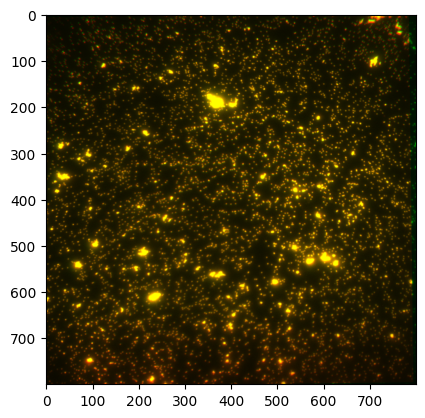

In [2]:
matrix_align = pipeline_chrom_ab_correction(nb_ref_frames = 10)

# Load the smFRET raw movies

This part is used to load the two first smFRET submovies and deinterleave the acceptor channel between AA and DA submovies. Just select the donor submovies, then the acceptor submovies. DD, DA and AA channels are stored in variables img_DD, img_DA and img_AA.

In [3]:
# load donor stack
img_stack_D, file_path_D = load_data()
# generate the calibrated donor movie
img_DD = generate_chrom_ab_corr_movie(img_stack_D, matrix_align)
# load acceptor stack
img_stack_A, file_path_A = load_data()
# desinterleave the acceptor raw channel
img_DA, img_AA = deinterleave_acceptor_channel(img_stack_A)

File '('D:/Bastien/M4/Cam1_D/d0 (1).tiff', 'D:/Bastien/M4/Cam1_D/d0 (2).tiff', 'D:/Bastien/M4/Cam1_D/d0 (3).tiff', 'D:/Bastien/M4/Cam1_D/d0 (4).tiff', 'D:/Bastien/M4/Cam1_D/d0 (5).tiff', 'D:/Bastien/M4/Cam1_D/d0 (6).tiff', 'D:/Bastien/M4/Cam1_D/d0 (7).tiff', 'D:/Bastien/M4/Cam1_D/d0 (8).tiff', 'D:/Bastien/M4/Cam1_D/d0 (9).tiff', 'D:/Bastien/M4/Cam1_D/d0 (10).tiff', 'D:/Bastien/M4/Cam1_D/d0 (11).tiff', 'D:/Bastien/M4/Cam1_D/d0 (12).tiff', 'D:/Bastien/M4/Cam1_D/d0 (13).tiff', 'D:/Bastien/M4/Cam1_D/d0 (14).tiff', 'D:/Bastien/M4/Cam1_D/d0 (15).tiff', 'D:/Bastien/M4/Cam1_D/d0 (16).tiff', 'D:/Bastien/M4/Cam1_D/d0 (17).tiff', 'D:/Bastien/M4/Cam1_D/d0 (18).tiff', 'D:/Bastien/M4/Cam1_D/d0 (19).tiff', 'D:/Bastien/M4/Cam1_D/d0 (20).tiff', 'D:/Bastien/M4/Cam1_D/d0 (21).tiff', 'D:/Bastien/M4/Cam1_D/d0 (22).tiff', 'D:/Bastien/M4/Cam1_D/d0 (23).tiff', 'D:/Bastien/M4/Cam1_D/d0 (24).tiff', 'D:/Bastien/M4/Cam1_D/d0 (25).tiff', 'D:/Bastien/M4/Cam1_D/d0 (26).tiff', 'D:/Bastien/M4/Cam1_D/d0 (27).tiff', 'D:

# Spot detection

The next section is used to detect the spots location among the raw movies. It first sums the two normalized DD and DA channels [normalization is (I(x,y) - min) / (max - min)] (min and max being the minimum and maximum values of each channel and whole 3D stack - not a min / max pair for individual frame), then Z-projects using the sum operation (can be changed to max by adding proj_oper = 'max' as extra input parameter). A rough background estimation is obtained using a median filter and the background is subtracted from the Z-project image.

The process then uses the LoG spot detector from the big-fish library to detect the spots on the Z-projected frame. The default parameters are kernel_size=2 and min_distance=2; this can be tuned upon needs as input parameters; see documentation for details.

The output of this step is a list of the xy coordinates of the detected spots; an image of the detection results is also displayed, for qualitative check.

*NB: you can notice two images are plotted: the left one is the Z-projected movies, and the right one is the same with the detected spots as round circles. This directly comes from the way the plot function is coded in the big-fish library. I will surely recode this plot function so it only displays the right one with the detected spots (when I have some time...)*

Start of the spots detection step...
Spot detection performed with sum Z-projection
614 spots detected


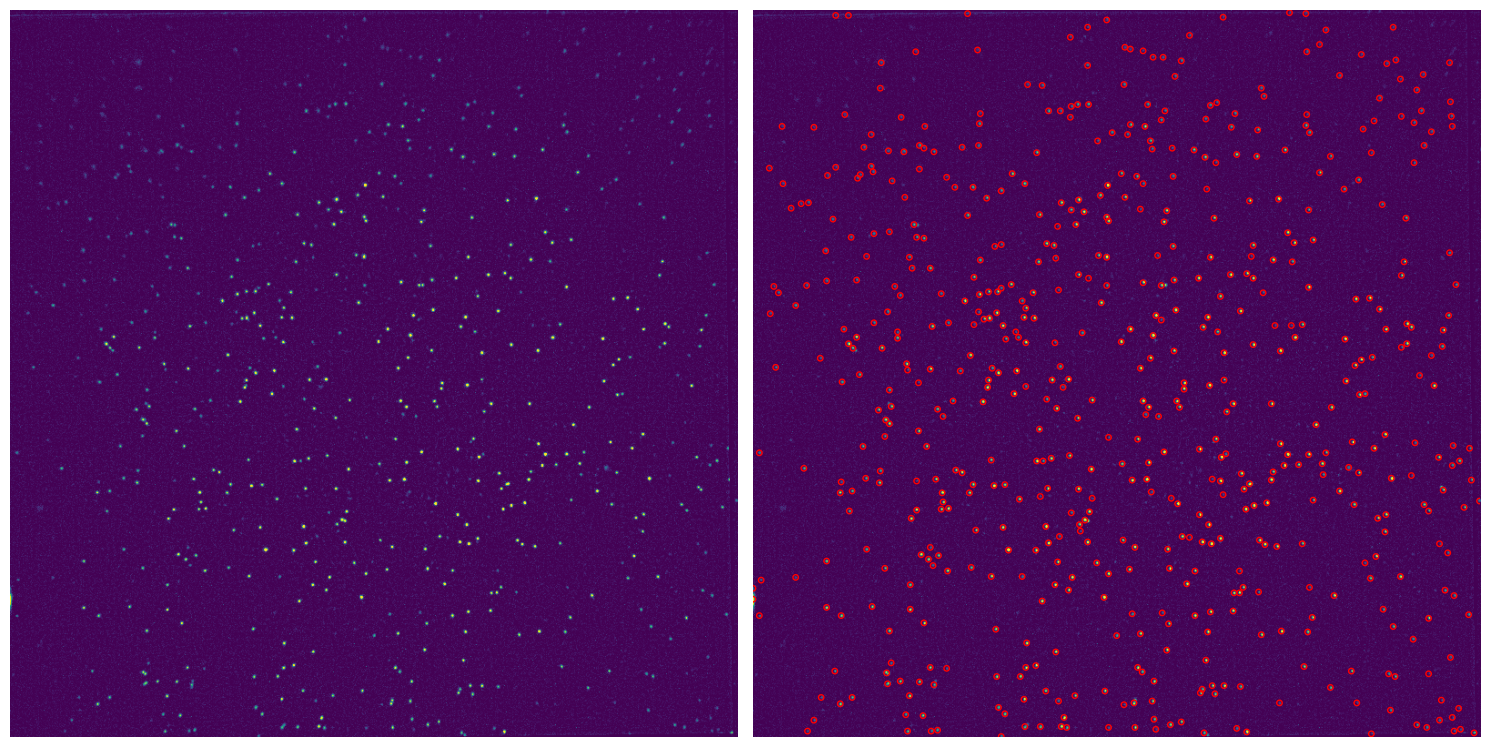

In [4]:
# detect the spots
coord_spots = detect_spot(img_DD, img_DA)

## Removal of the cluster of spots

Some spots are close to each other, which might disturb the trace extraction and analysis (multiple donors / acceptor for one single traces...); we want to get rid of these. The minimal distance we consider that should be between two spots is set to 7 pixels, this can be tuned as well: all pairs of spots with interspot distance less than 7 pixels will be removed from the analysis.

In [5]:
#filter the clustered spots
coord_spots_filter = filter_close_prox_spots(coord_spots, min_dist = 7)

Removing the clusters of spots (interspots distance less than 7 pixels)
584 remaining spots (30 spots removed)


# Spot traces extraction from submovies

In this section, the pipeline loads one submovie at a time and search for the maximal pixel intensity inside a search area for each individual spot. This search area is set to be a circle with radius = 5 pixels (can be tuned). This should handle small drift of the xy stage , as the detected spot coordinates are the one from the first submovie, and they also might be slightly inaccurate. Through this process, subtraces are extracted and stacked into a variable (dictionnary) that contains all individual spots' traces. By iterating over all submovies, the full traces are extracted and concatenated.

*NB: the donor submovies are automatically corrected for chromatic aberrations (that is why the transformation matrix matrix_align is provided as input parameter).*

In [6]:
# extract DD and DA traces
traces_data = spot_trace_extractor(coord_spots_filter, img_DD, file_path_D, img_stack_A, file_path_A, matrix_align)

Start of the traces extraction and concatenation step...
Extracting traces from movie 0...
Extracting traces from movie 1...
Extracting traces from movie 2...
Extracting traces from movie 3...
Extracting traces from movie 4...
Extracting traces from movie 5...
Extracting traces from movie 6...
Extracting traces from movie 7...
Extracting traces from movie 8...
Extracting traces from movie 9...
Extracting traces from movie 10...
Extracting traces from movie 11...
Extracting traces from movie 12...
Extracting traces from movie 13...
Extracting traces from movie 14...
Extracting traces from movie 15...
Extracting traces from movie 16...
Extracting traces from movie 17...
Extracting traces from movie 18...
Extracting traces from movie 19...
Extracting traces from movie 20...
Extracting traces from movie 21...
Extracting traces from movie 22...
Extracting traces from movie 23...
Extracting traces from movie 24...
Extracting traces from movie 25...
Extracting traces from movie 26...
Extracti

# Detection of the bleaching events

In order to calculate the SNR and other quality metrics, we need to detect the bleaching events for each traces. This is a challenging step, as some of the traces don't show any bleaching events, either because of a long lifetime of donor / acceptor or because the trace is in fact just noise. To tackle this issue, we calculate the median signal level of the first 5% frames (can be tuned) and the one for the 5% last frames, and we substract the two: if this is less than one standard deviation of the last 5% signal level, then we consider that the signal level is not significant enough to be taken as a real signal, and we set its bleaching event to 0. We are doing this for the DD and AA traces.

If the trace (DD or AA) passes the test, we run the KernelCPD function from the ruptures library, with the model 'linear' as default (can be changed), that will search for exactly one break event in the signal (likely the bleaching event). The output of this function is the frame of the detected break event. We iterate this process for all DD and AA channels of all traces.

The output of this step is an updated traces dictionary with additional parameters 'bleaching_event_DD' and 'bleaching_event_AA' for all traces.

In [7]:
# detect bleaching event
traces_data = detect_bleaching_event(traces_data)

Start of the bleach point detection step...
1 / 584 processed
2 / 584 processed
3 / 584 processed
4 / 584 processed
5 / 584 processed
6 / 584 processed
7 / 584 processed
8 / 584 processed
9 / 584 processed
10 / 584 processed
11 / 584 processed
12 / 584 processed
13 / 584 processed
14 / 584 processed
15 / 584 processed
16 / 584 processed
17 / 584 processed
18 / 584 processed
19 / 584 processed
20 / 584 processed
21 / 584 processed
22 / 584 processed
23 / 584 processed
24 / 584 processed
25 / 584 processed
26 / 584 processed
27 / 584 processed
28 / 584 processed
29 / 584 processed
30 / 584 processed
31 / 584 processed
32 / 584 processed
33 / 584 processed
34 / 584 processed
35 / 584 processed
36 / 584 processed
37 / 584 processed
38 / 584 processed
39 / 584 processed
40 / 584 processed
41 / 584 processed
42 / 584 processed
43 / 584 processed
44 / 584 processed
45 / 584 processed
46 / 584 processed
47 / 584 processed
48 / 584 processed
49 / 584 processed
50 / 584 processed
51 / 584 proces

# Calculation of the SNR for each traces

This step is used to calculate the SNR for each traces and each channels (DD, DA and AA). The SNR is set to 0 if the bleach event is 0, for DD or AA channels; and set to 0 for DA if both DD and AA bleach event are 0. Otherwise, the SNR is defined as the (mean signal - mean noise level) / std noise level, with the noise level taken as the section after the bleaching event for DD or AA, and for the min(DD bleach event, AA bleach event) for the DA noise level.

The output of this step is an updated traces dictionnary with additonal parameters SNR_DD, SNR_DA and SNR_AA for each traces.

In [8]:
# calculate SNR for each traces
traces_data = get_SNR(traces_data)

Start of the SNR calculation step...
SNR calculation step completed!


We then filter the traces based on their SNR, with a threshold for both SNR_DD and SNR_AA, default value is SNR = 8. The ouput is a new dictionary where only traces with high SNR for both DD and AA channels are taken; we also collect a list of the traces IDs that are selected for high SNR (this list might be useless, I keep it for now, but will likely remove it from outputs if we don't use it in the downstream analysis.

In [9]:
# filter only high SNR traces
traces_high_SNR, list_highSNR_IDs = filter_traces_on_SNR(traces_data, SNR_thresh = 8)

Start of the high SNR traces filter step...
High SNR traces filter step completed!


We finally plot the first 5 traces that have been filtered as high SNR traces; you can plot the 5 following traces starting to a given number by adding the optional parameter traces_ID = 10 (in this example, we plot the traces 10, 11, 12, 13 and 14); we can also plot more or less traces using the optional parameter nb_plot = 5. (See the documentation for more details and extra parameters)

*NB: the bleach events for DD and AA traces are displayed with vertical lines.*

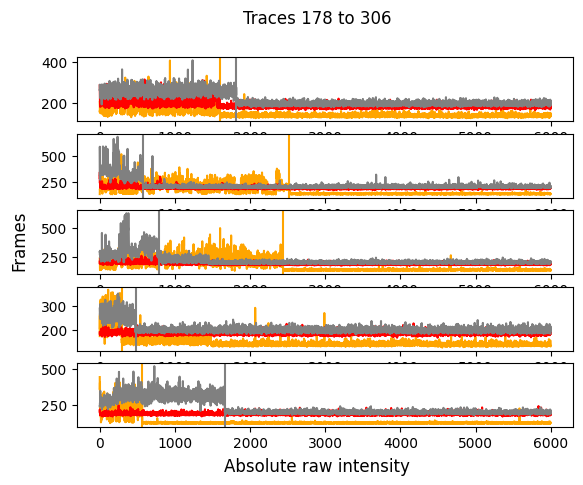

In [10]:
plot_multiple_traces(traces_high_SNR)

## Add the chromatic aberrations correction matrix to the traces dictionary

This step is simply to add the chromatic aberrations correction matrix to the traces dictionary as metadata. A field ''chromatic_aberration_corr_matrix'' is created and contained the matrix as numpy array.

In [11]:
# add the matrix to the high SNR filtered traces dataset
traces_high_SNR = add_trans_matrix_to_traces_dict(traces_high_SNR, matrix_align)

# also add the matrix to the unfiltered traces dataset
traces_data = add_trans_matrix_to_traces_dict(traces_data, matrix_align)

# Save the traces dataset as JSON file

Last step of this pipeline is to save the traces dataset into a JSON file, so it can be retrieved easily for downstream analysis. Just run the following cell and create the JSON file that will contain the traces dictionary; please make sure the extension of the file is .json
You can choose if you want to save the high SNR filtered traces dataset or the non-filtered one; for generality purposes, I suggest to save the non-filtered one, as we can still refine it during the downstream analysis.

In [15]:
save_traces_dict(traces_data)

TypeError: Object of type int64 is not JSON serializable

*NB: The JSON traces dataset can be loaded using the function load_JSON_traces_data(). It simply asks you to select the JSON file and loads it into a new dictionary.*

In [ ]:
traces_dataset = load_JSON_traces_data()

## End of the pipeline

The next module will be the traces quality scoring, which will be used to refine the traces dataset and only keep the traces with high quality metrics.

Please provide some feedbacks on this current traces extractor module by opening new issues in the column 'Users feedback' in the PySMACKS project, so we can continously improve our workflow, thanks!